In [ ]:
from koala.lattice import Lattice
import numpy as np
import numpy.typing as npt
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.flux_finder import ujk_from_fluxes, fluxes_from_ujk
from koala import plotting as pl
from tqdm import tqdm

import scipy
from scipy.special import logsumexp

from pfapack.ctypes import pfaffian
import pfapack.ctypes as cpf
import ctypes
from scipy import linalg as la
from matplotlib import pyplot as plt
from dimer_models.lattice_generation import expand_edges_to_squares
from dimer_models.kasteleyn import (
    kasteleyn_matrix,
    _fast_pfaffian,
    find_kasteleyn_number,
)

In [ ]:
def hex_with_every_other(n, every_other, return_lat_and_mask=False):
    center = 0.5 + 1 / (4 * n)
    lattice = eg.honeycomb_lattice(n)
    edge_centers = np.mean(lattice.vertices.positions[lattice.edges.indices], axis=1)

    # kitaev edge labels
    edge_angles = np.arctan2(*lattice.edges.vectors.T) % np.pi
    _, edge_labels = np.unique(np.round(edge_angles, 2), return_inverse=True)

    # Create a mask for edges that are chosen
    vert_edge_centers = edge_centers[edge_labels == 0]
    _, edge_column = np.unique(vert_edge_centers[:, 0], return_inverse=True)
    print(len(_))

    mask = np.zeros(lattice.n_edges, dtype=bool)
    mask[edge_labels == 0] = edge_column % every_other == 0
    mask = mask * (edge_labels == 0)  # Only keep edges with label 0
    out = expand_edges_to_squares(lattice, np.where(mask)[0])
    if return_lat_and_mask:
        return out, lattice, mask

    return out


def pbc_pfaffian(matrix, pow_form=False):
    real_part = matrix.real
    imag_part = matrix.imag

    anti_sym = np.block([[real_part, imag_part], [-imag_part, real_part]])

    assert np.sum(anti_sym + anti_sym.T) == 0

    if pow_form:
        return _fast_pfaffian(anti_sym)

    return pfaffian(anti_sym)


def honeycomb_unit_cell(tiling):

    vertices = np.array([[1, 1], [2, 2]]) / 3
    edges = np.array([[0, 1], [1, 0], [1, 0]])
    crossing = np.array([[0, 0], [0, 1], [1, 0]])
    l = Lattice(vertices, edges, crossing)

    return gu.tile_unit_cell(vertices, edges, crossing, tiling)


def triangular_lattice(tiling):
    vertices = np.array([[1, 1]]) / 2
    edges = np.array([[0, 0], [0, 0], [0, 0]])
    crossing = np.array([[1, 0], [0, 1], [1, 1]])
    l = Lattice(vertices, edges, crossing)

    return gu.tile_unit_cell(vertices, edges, crossing, tiling)

fluxes are:[-1 -1 -1]


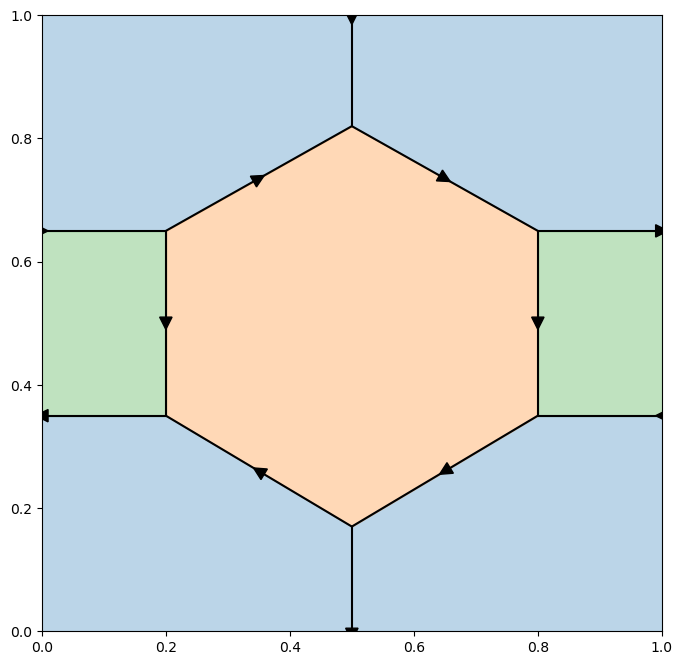

In [147]:
# define unit cell

unit_cell = eg.hex_square_oct_lattice(1)

# confined - sqoc
# unit_cell = gu.com_relaxation(hex_with_every_other(1, 1))

# honeycomb
# unit_cell = triangular_lattice((2, 2))
# unit_cell = honeycomb_unit_cell([1,1])


orientation = ujk_from_fluxes(unit_cell, [-1] * unit_cell.n_plaquettes)
fluxes = fluxes_from_ujk(unit_cell, orientation)
print(f"fluxes are:{fluxes}")

fig, ax = plt.subplots(figsize=(8, 8))
pl.plot_edges(
    unit_cell,
    directions=orientation,
)

colors = plt.Colormap("tab20")


cmap = plt.get_cmap("tab10")
plaq_labels = np.arange(unit_cell.n_plaquettes)
color_scheme = cmap(plaq_labels % 10)
#
pl.plot_plaquettes(unit_cell, labels=plaq_labels, color_scheme=color_scheme, alpha=0.3)
plt.show()

0.0


/var/folders/v4/z7wcc4gj6clczcj6vr8b9dvw0000gn/T/ipykernel_42387/395702081.py:23: RuntimeWarning: divide by zero encountered in log
  log = ax[1].matshow(np.log(pfaffians), cmap="terrain_r")


Text(0.5, 1.0, 'log pfaffian values')

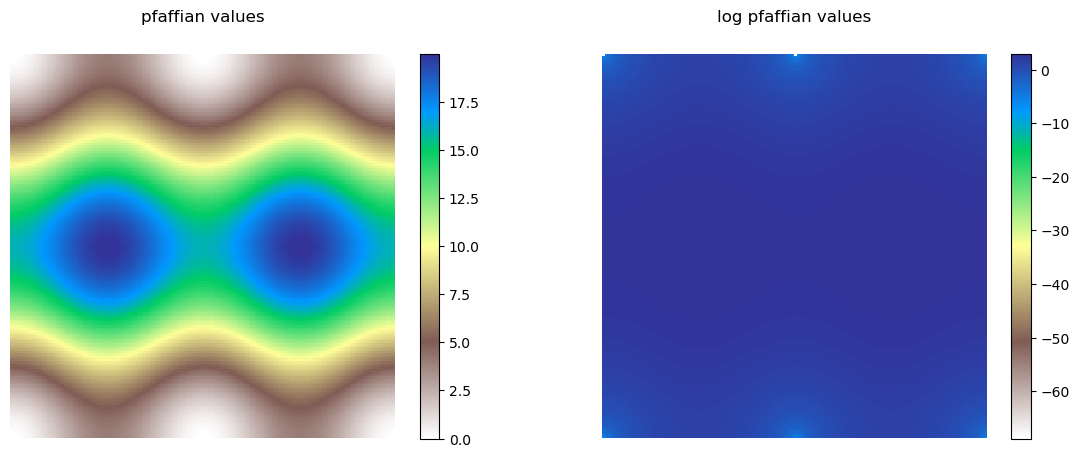

In [148]:
# plot band structure
n = 150

k_vals = np.linspace(0, 2 * np.pi, n, endpoint=False)
kx, ky = np.array(np.meshgrid(k_vals, k_vals))

pfaffians = np.zeros_like(kx.flatten())

for i, k in enumerate(zip(kx.flatten(), ky.flatten())):

    h = kasteleyn_matrix(unit_cell, orientation, k)

    assert la.ishermitian(1j * h)
    pfaffians[i] = pbc_pfaffian(h)

    # pfaffians[i] = np.abs(pfaffian(h))


pfaffians = pfaffians.reshape(kx.shape)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
re = ax[0].matshow(pfaffians, cmap="terrain_r", clim=(0, np.max(np.abs(pfaffians))))
log = ax[1].matshow(np.log(pfaffians), cmap="terrain_r")
plt.colorbar(re, ax=ax[0])
plt.colorbar(log, ax=ax[1])
print(np.min(pfaffians))
for a in ax:
    a.set_axis_off()
ax[0].set_title("pfaffian values")
ax[1].set_title("log pfaffian values")

In [ ]:
from scipy.special import logsumexp

# now we do the scaling argument

# todo - fix this to only look at the half plane

results = []
scaling_resolutions = np.arange(1, 30, 1)
for s in scaling_resolutions:
    k = np.linspace(-np.pi, np.pi, s, endpoint=False)

    KX, KY = np.meshgrid(k, k)

    k_vals = np.array([KX.flatten(), KY.flatten()]).T

    pfaffs = np.zeros((len(k_vals), 4))
    pows = np.zeros((len(k_vals), 4))

    for j, k in enumerate(k_vals):

        for i, shift in enumerate(([0, 0], [0, 1], [1, 0], [1, 1])):

            h = kasteleyn_matrix(
                unit_cell, orientation, k + np.array(shift) * np.pi / s
            )
            pf, pow = pbc_pfaffian(h, True)
            pfaffs[j, i] = pf
            pows[j, i] = pow

    pow_lims = np.max(pows, axis=0)
    pow_shifts = pows - pow_lims

    pfaffs_shifted = pfaffs * 10**pow_shifts
    print(np.prod(pfaffs_shifted, axis=0) * 10**pow_lims + 1 - 1)

    break

    result = np.sum(pfaffs, axis=0)
    results.append(result)
results = np.array(results)

[16.  0. 16.  0.]


In [150]:
find_kasteleyn_number(unit_cell)

4

In [151]:
matrix = np.random.random((2, 2)) + 1j * np.random.random((2, 2))
matrix = matrix - matrix.T.conj()

print(la.det(matrix).real)
print(pbc_pfaffian(matrix))

-0.4822980216784994
-0.4822980216784995
